#  Medical Insurance Price Prediction using Linear Regression

## Problem Statement

Medical insurance charges are different for every person. They depend on factors like age, BMI, smoking habits, number of children, gender, and region.
In this project, I built a Linear Regression model to predict a person's medical insurance charges based on these details.

# Dataset

The dataset contains information about people and their medical insurance charges.

### Features

- Age – Age of the person
- Gender – Male or Female
- BMI – Body Mass Index
- Children – Number of children
- Smoker – Whether the person smokes or not
- Region – Residential region
- Charges – Medical insurance cost (Target Variable)


## Objective

The main objective of this project is to:

- Understand the dataset.
- Explore the data using EDA.
- Prepare the data for training.
- Build a Linear Regression model.
- Predict medical insurance charges.
- Evaluate the model's performance.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Import Libraries

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [164]:
df=pd.read_csv("insurance.csv")

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset before building a machine learning model.

It helps identify:

- Missing values
- Data types
- Feature distributions
- Relationships between variables
- Outliers

In [165]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [167]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [168]:
df.shape

(1338, 7)

In [169]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [170]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [171]:
df.duplicated().sum()

np.int64(1)

In [172]:
df = df.drop_duplicates()

# 1. Insurance Charges Distribution


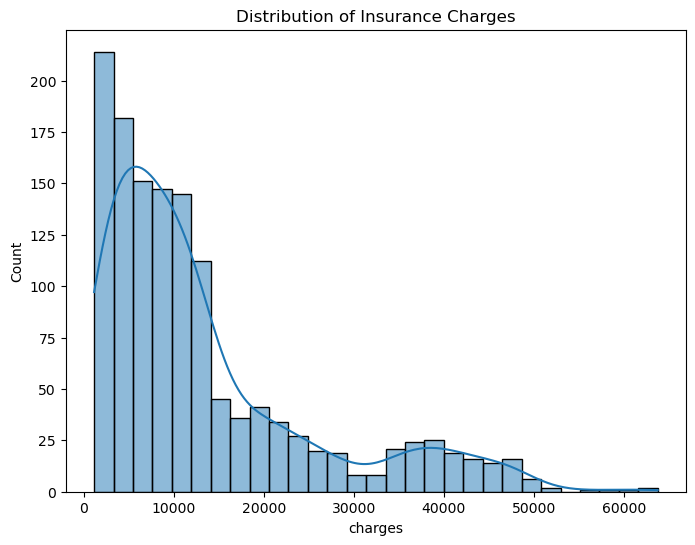

In [173]:
plt.figure(figsize=(8,6))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Insurance Charges")
plt.savefig("Images/charges_distribution.png", dpi=300)
plt.show()

# 2. Age Distribution


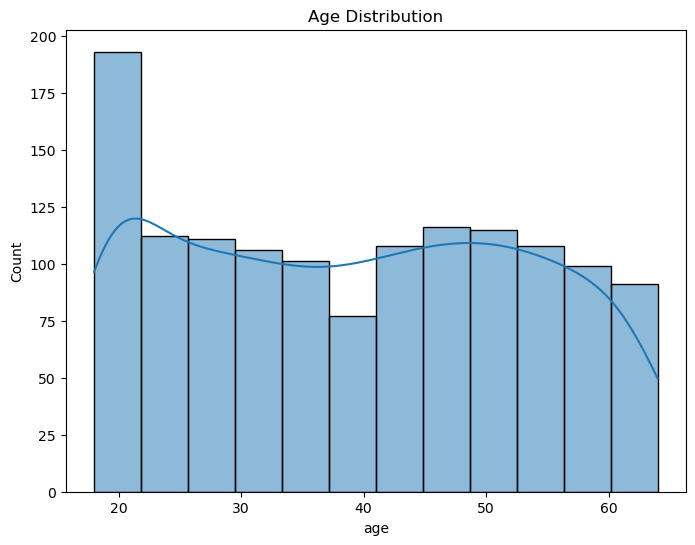

In [174]:
plt.figure(figsize=(8,6))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.savefig("Images/age_distribution.png", dpi=300)
plt.show()

# 3. BMI Distribution


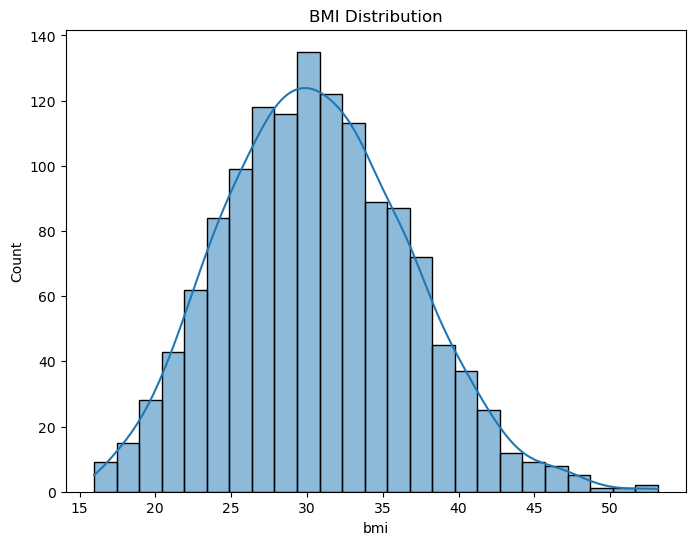

In [175]:
plt.figure(figsize=(8,6))
sns.histplot(df["bmi"], kde=True)
plt.title("BMI Distribution")
plt.savefig("Images/bmi_distribution.png", dpi=300)
plt.show()

# 4. Smoker vs Non-Smoker


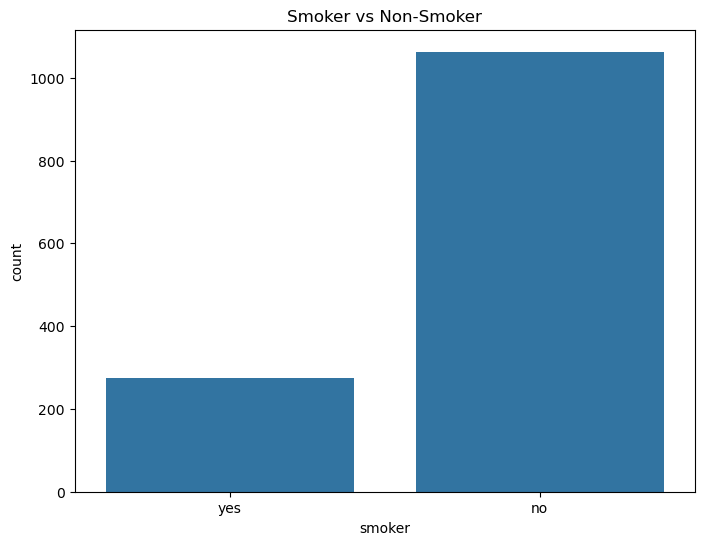

In [176]:
plt.figure(figsize=(8,6))
sns.countplot(x="smoker", data=df)
plt.title("Smoker vs Non-Smoker")
plt.savefig("Images/SmokervsNonSmoker_distribution.png", dpi=300)
plt.show()

# Correlation Heatmap

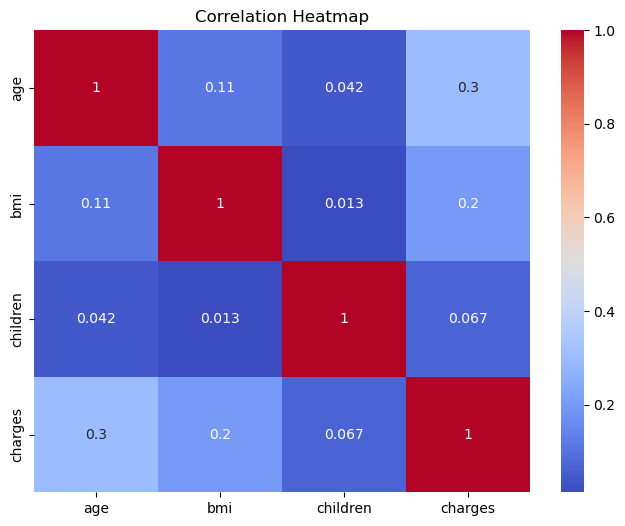

In [177]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 📈 Simple Linear Regression

Simple Linear Regression uses one independent feature to predict the target variable.

In this project, I used Age  to predict Insurance Charges.

In [178]:
X=df[["age"]]
y=df["charges"]

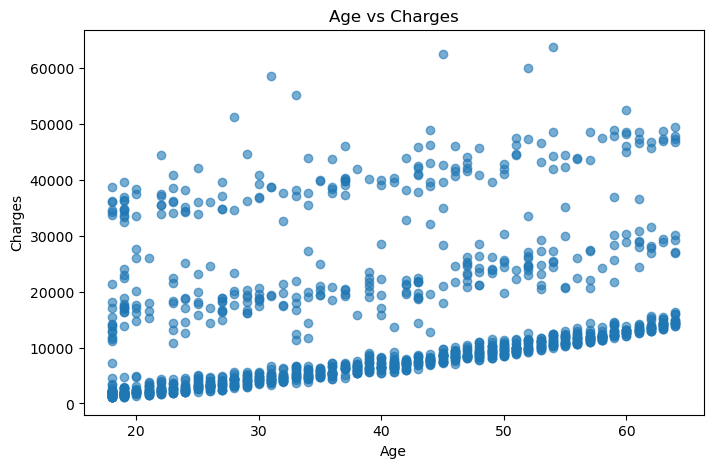

In [179]:
plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

In [180]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.4, random_state=42)

In [181]:
model=LinearRegression()

In [182]:
model.fit(X_train,y_train)

LinearRegression()

In [183]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [251.29757077]
Intercept: 3202.9074717321673


In [184]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[15516.48843954 10490.53702411 16019.08358109 10993.13216565
 10993.13216565 15516.48843954  8982.75159948  8731.45402871
 14008.70301491 15516.48843954]


In [185]:
comparison=pd.DataFrame({
    "Actual":y_test.values,
    "predicted":y_pred})
print(comparison)

          Actual     predicted
0     8688.85885  15516.488440
1     5708.86700  10490.537024
2    11436.73815  16019.083581
3    38746.35510  10993.132166
4     4463.20510  10993.132166
..           ...           ...
530   8733.22925  14762.595727
531   3558.62025   9987.941883
532   2585.85065   8480.156458
533  10156.78320  15516.488440
534  43921.18370  17275.571435

[535 rows x 2 columns]


# 📏 Model Evaluation

The trained model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [186]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", MAE)
print("Mean Squared Error:", MSE)
print("Root Mean Squared Error:", RMSE)
print("R² Score:", R2)

Mean Absolute Error: 9353.080934502097
Mean Squared Error: 151658466.23997894
Root Mean Squared Error: 12314.969193626874
R² Score: 0.08292161102423146


## Visualization

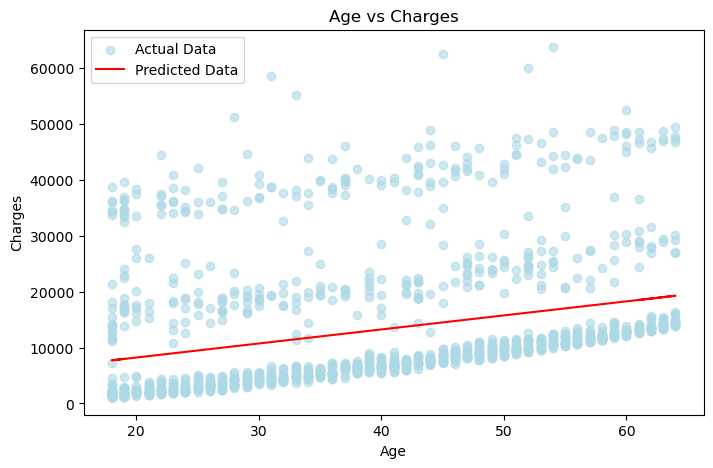

In [187]:
plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.6, color="lightblue", label="Actual Data")
plt.plot(X,model.predict(X), color="red",label="Predicted Data")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.legend()

plt.show()

# ⚙️ Data Preprocessing

Before training the model, categorical features must be converted into numerical values because machine learning algorithms work only with numerical data.

In [188]:
df["smoker"] = df["smoker"].str.strip().str.lower()

In [189]:
df["smoker"] = df["smoker"].map({ "no": 0, "yes": 1})
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [190]:
print(df.isnull().sum())
print(df["smoker"].unique())
print(df["sex"].unique())

print(df.dtypes)

age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64
[1 0]
[1 0]
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


# 📈 Multiple Linear Regression

Multiple Linear Regression uses multiple independent features to predict the target variable.


In [191]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


In [192]:
X = df_model.drop("charges", axis=1)
y = df_model["charges"]

In [193]:
X["age_bmi"] = X["age"] * X["bmi"]

if "smoker_yes" in X.columns:
    X["smoker_bmi"] = X["smoker_yes"] * X["bmi"]
    X["age_smoker"] = X["smoker_yes"] * X["age"]

In [194]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [195]:
model=LinearRegression()

In [196]:
model.fit(X_train,y_train)

LinearRegression()

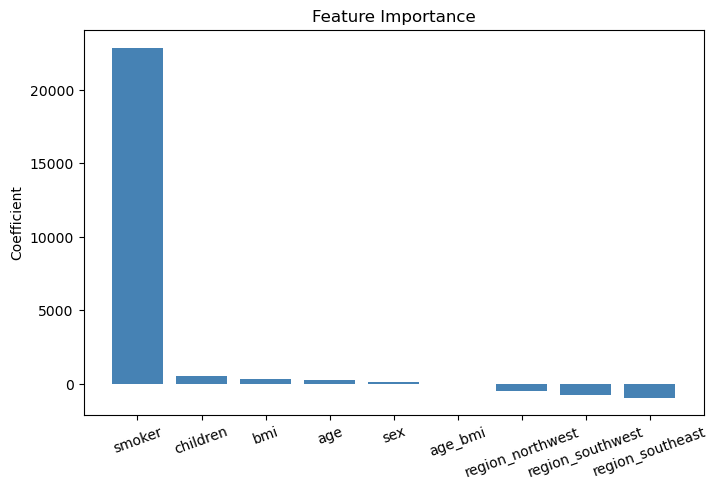

In [197]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(coefficients["Feature"], coefficients["Coefficient"], color="steelblue")
plt.title("Feature Importance")
plt.ylabel("Coefficient")
plt.xticks(rotation=20)
plt.show()

In [198]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_})

coefficients.sort_values(
    by="Coefficient",
    ascending=False)

,Feature,Coefficient
4,smoker,22871.592478
3,children,521.916097
2,bmi,339.250499
0,age,260.184988
1,sex,111.336346
8,age_bmi,-0.289103
5,region_northwest,-466.495915
7,region_southwest,-763.782847
6,region_southeast,-938.566611


In [199]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[ 8107.58642256  5490.01088579 14326.42828896 31434.43989986
  8890.01382791 13087.49321129 30246.74479732  1200.10157893
 10569.71745424 11214.2352261 ]


In [200]:
comparison=pd.DataFrame({
    "Actual":y_test.values,
    "predicted":y_pred})
print(comparison)

          Actual     predicted
0     8688.85885   8107.586423
1     5708.86700   5490.010886
2    11436.73815  14326.428289
3    38746.35510  31434.439900
4     4463.20510   8890.013828
..           ...           ...
397   5148.55260   7406.592509
398  11363.28320  13826.577568
399  10600.54830  12206.659216
400  13429.03540  13576.900243
401  24603.04837   8240.240743

[402 rows x 2 columns]


## 📏 Model Evaluation

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² ScoreModel Evaluation

In [201]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", MAE)
print("Mean Squared Error:", MSE)
print("Root Mean Squared Error:", RMSE)
print("R² Score:", R2)

Mean Absolute Error: 4180.857885276582
Mean Squared Error: 38948686.6937367
Root Mean Squared Error: 6240.888293643518
R² Score: 0.7723865804455268


## Visualization

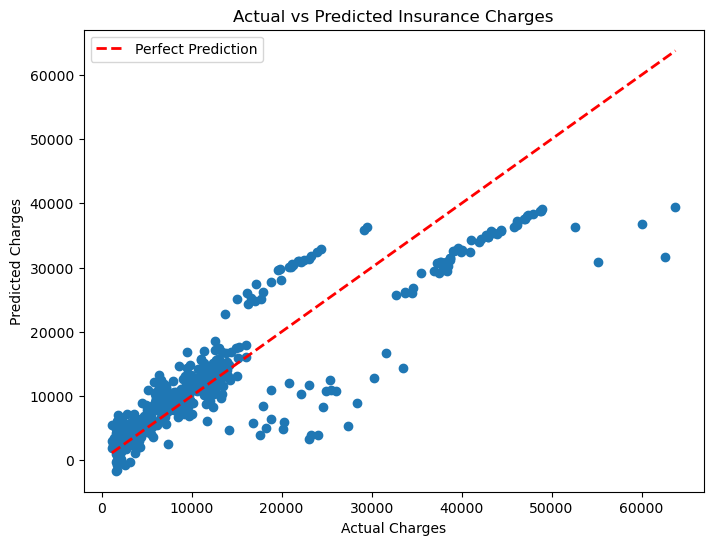

In [202]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot( [y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.show()

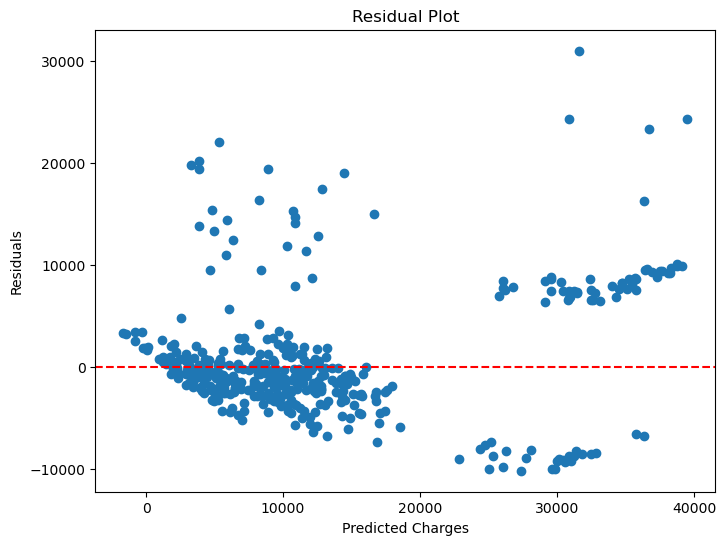

In [203]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

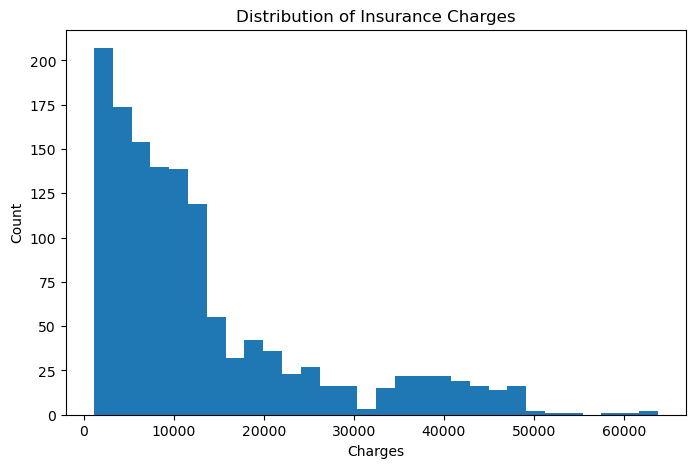

In [204]:
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.xlabel("Charges")
plt.ylabel("Count")
plt.title("Distribution of Insurance Charges")
plt.show()

In [205]:
print(model.feature_names_in_.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'age_bmi']


In [206]:
sample = pd.DataFrame({
    "age": [30],
    "sex": [1],
    "bmi": [28.5],
    "children": [2],
    "smoker": [0],
    "region_northwest": [0],
    "region_southeast": [1],
    "region_southwest": [0],
    "age_bmi": [30 * 28.5],
  
})

prediction = model.predict(sample)

print("Medical Charges Prediction\n")

print("Age        :", 30)
print("Sex        : Male")
print("BMI        :", 28.5)
print("Children   :", 2)
print("Smoker     : No")
print("Region     : Southeast\n")

print(f"Predicted Insurance Charges : ${prediction[0]:,.2f}")


Medical Charges Prediction

Age        : 30
Sex        : Male
BMI        : 28.5
Children   : 2
Smoker     : No
Region     : Southeast

Predicted Insurance Charges : $5,482.85


## Conclusion

In this project, I built a Linear Regression model to predict medical insurance charges.

During this project, I:
- Explored the dataset
- Cleaned and prepared the data
- Built Simple and Multiple Linear Regression models
- Compared their performance
- Predicted insurance charges for new data

I learned that using multiple features gives better predictions than using only one feature.

## Model Comparison

| Model | R² Score |
|--------|---------:|
| Simple Linear Regression | 0.09 |
| Multiple Linear Regression | 0.771 |

Multiple Linear Regression performed much better than Simple Linear Regression.